In [31]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/client_hostname[1].csv')
df = df.dropna()

# Expand dataset (simulate multiple actions)
df = pd.concat([df]*10, ignore_index=True)

# Shuffle data
df = df.sample(frac=1).reset_index(drop=True)

# Use client as user
df['user_id'] = df['client']

In [32]:
df['timestamp'] = pd.date_range(start='2024-01-01', periods=len(df), freq='S')

/tmp/ipykernel_2017/4141799793.py:1: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df['timestamp'] = pd.date_range(start='2024-01-01', periods=len(df), freq='S')


In [33]:
df['activity'] = 1

df = df.sort_values(['user_id', 'timestamp'])

df['time_diff'] = df.groupby('user_id')['timestamp'].diff().dt.seconds

In [39]:
# Attacker 1: high activity
df.loc[:200, 'user_id'] = 'ATTACKER_1'

# Attacker 2: fast requests (bot)
df.loc[200:400, 'user_id'] = 'ATTACKER_2'

# Attacker 3: unusual browsing diversity
df.loc[400:600, 'user_id'] = 'ATTACKER_3'

In [40]:
user_behavior = df.groupby('user_id').agg({
    'activity': 'sum',
    'hostname': 'nunique',
    'time_diff': ['mean', 'std']
}).reset_index()

user_behavior.columns = [
    'user_id',
    'total_activity',
    'unique_sites',
    'avg_time_gap',
    'std_time_gap'
]

In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

X = user_behavior.drop(columns=['user_id'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = IsolationForest(contamination=0.1)
user_behavior['anomaly'] = model.fit_predict(X_scaled)

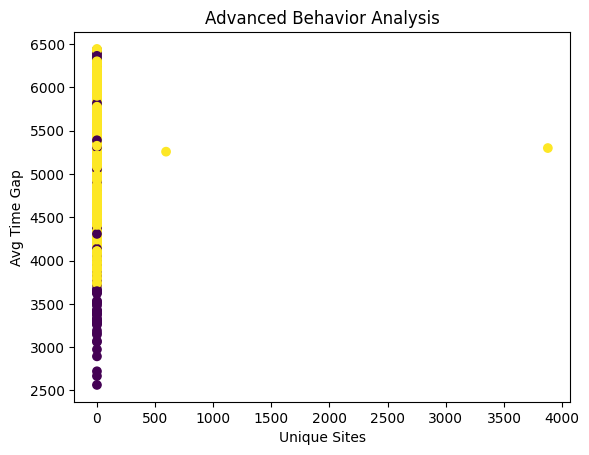

In [42]:
import matplotlib.pyplot as plt
plt.scatter(user_behavior['unique_sites'],
            user_behavior['avg_time_gap'],
            c=user_behavior['anomaly'])

plt.xlabel("Unique Sites")
plt.ylabel("Avg Time Gap")
plt.title("Advanced Behavior Analysis")

plt.show()